# Building an Autograd Engine from Scratch

Before diving into neural networks, we need an engine that can track mathematical operations and automatically compute gradients. We start with standard numerical and visualization libraries.

To understand what actually happens under the hood, I spent some time following Andrej Karpathy's micrograd tutorial. This notebook is my implementation of his guide. The goal here isn't to invent something new, but to showcase the foundational math and structure of building a scalar autograd engine from absolute scratch in pure Python. No magic, just calculus and computation graphs.

In [116]:
import math
import numpy as np
import matplotlib.pyplot as plt

## The Intuition Behind Derivatives

Consider a simple quadratic function:
$$f(x) = 3x^2 - 4x + 5$$

Understanding how this function responds to tiny changes in $x$ is the foundational concept of gradient descent.

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [118]:
f(3.0)

20.0

We can use matplotlib to make sense the shape of our function

[100.      91.6875  83.75    76.1875  69.      62.1875  55.75    49.6875
  44.      38.6875  33.75    29.1875  25.      21.1875  17.75    14.6875
  12.       9.6875   7.75     6.1875   5.       4.1875   3.75     3.6875
   4.       4.6875   5.75     7.1875   9.      11.1875  13.75    16.6875
  20.      23.6875  27.75    32.1875  37.      42.1875  47.75    53.6875]


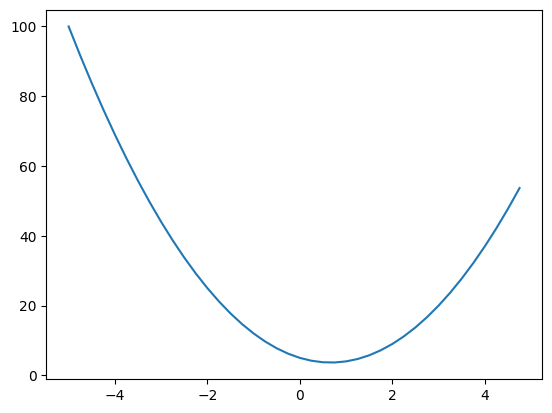

In [119]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
print(ys)
plt.plot(xs, ys)

### Numerical Approximation of the Derivative

By the formal definition of a derivative, we evaluate the limit as $h$ approaches zero:
$$L = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

Here, we approximate this by using a very small floating-point value for $h$. This gives us the slope (or gradient) of the function at a specific point.

In [3]:
# if we nudge x by h, what sort of response will we get?
h = 0.000001
x = 3.0
(f(x + h) - f(x))/h

14.000003002223593

## Partial Derivatives in Multi-Variable Functions

Neural networks operate on multiple parameters (weights and biases). Let's define a function with multiple inputs:
$$d(a, b, c) = a \cdot b + c$$

We want to understand the partial derivative of $d$ with respect to each input. For example, $\frac{\partial d}{\partial a}$ tells us how much the output changes if we slightly nudge $a$.

In [ ]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [122]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a+=h #bump by h
d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


## Micrograd

To automate gradient computation, we use a data structure that wraps numerical values and records all operations performed on them. This builds a **Directed Acyclic Graph (DAG)** representing the computation.

This system relies on the **Chain Rule** from calculus. For a composite function $f(g(x))$, the derivative is:

$$
\frac{df}{dx} = \frac{df}{dg} \cdot \frac{dg}{dx}
$$

Each operation defines:
- A **local derivative** $\frac{df}{dg}$
- Which is multiplied by the **incoming gradient** $\frac{dg}{dx}$ during backpropagation

---

### Addition (`__add__`)

**Forward Pass:**

For two scalar values $x$ and $y$:
$$
s = x + y
$$

**Backward Pass:**

The derivative of $s$ with respect to both $x$ and $y$ is 1:

$$
\frac{\partial s}{\partial x} = 1, \quad \frac{\partial s}{\partial y} = 1
$$

So the gradient is passed equally to both inputs.

---

### Multiplication (`__mul__`)

**Forward Pass:**

$$
p = x \cdot y
$$

**Backward Pass:**

$$
\frac{\partial p}{\partial x} = y, \quad \frac{\partial p}{\partial y} = x
$$

Each input receives the gradient scaled by the other input.

---

### Power (`__pow__`)

**Forward Pass:**

$$
p = x^n
$$

**Backward Pass:**

Using the power rule:

$$
\frac{\partial p}{\partial x} = n \cdot x^{n-1}
$$

The backward gradient is this value multiplied by the upstream gradient.

---

### Exponential (`exp`)

**Forward Pass:**

$$
e = e^x
$$

**Backward Pass:**

$$
\frac{d}{dx}(e^x) = e^x
$$

So the gradient is multiplied by the output itself.

---

### Hyperbolic Tangent (`tanh`)

**Forward Pass:**

$$
t = \tanh(x)
$$

**Backward Pass:**

$$
\frac{d}{dx}(\tanh(x)) = 1 - \tanh^2(x) = 1 - t^2
$$

---

### Composite Operations (`__neg__`, `__sub__`, `__truediv__`)

We do not explicitly define backward passes for these operations. Instead, they are expressed using fundamental operations:

- Negation: $-x = x \cdot (-1)$  
- Subtraction: $x - y = x + (y \cdot -1)$  
- Division: $x / y = x \cdot y^{-1}$  

Because they are built from basic operations, their gradients are automatically handled through the computation graph using the chain rule.

Notice how we are overriding Python's built-in dunder methods (like `__add__` and `__mul__`). This allows us to use normal Python math operators (`+`, `*`) while secretly building our computation graph in the background. Every time an operation happens, we store the result *and* a recipe (the `_backward` function) on how to compute its local derivative later.

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data = {self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')
        
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        
        return out
        
    def __truediv__(self, other): # self / order
        return self * other ** -1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __radd__(self, other): # other + self
        return self + other
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
            
        out._backward = _backward
        
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
            
        out._backward = _backward
        
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

### Why the Topological Sort?
During backpropagation, a node cannot calculate its gradient until the node ahead of it has passed its gradient backward.

A topological sort guarantees that we process the nodes in the exact reverse order of how they were created, ensuring the chain rule flows perfectly from the output back to the inputs.

## Visualizing the Computation Graph

We use the `graphviz` library to traverse our DAG recursively and plot the nodes (values) and edges (operations) to see exactly how our math flows.

In [7]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad, ), shape='record')
        if n._op:
            #if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

## Backpropagating Through a Single Neuron

Before we build a full Multi-Layer Perceptron, let's zoom in on a single artificial neuron to see our `Value` engine in action.

A neuron is fundamentally a mathematical operation loosely inspired by biology. It takes in multiple inputs ($x$), multiplies each by a specific weight ($w$), sums them all together, and adds a bias ($b$). Finally, it squashes that raw linear sum through an activation function (we are using $\tanh$) to introduce non-linearity.

<img src="neuron.png" width="400" />

The forward pass formula looks like this:
$$o = \tanh(w_1x_1 + w_2x_2 + b)$$

Let's model this exact equation using our engine. Notice how we are building the computation graph step-by-step.

In [181]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870196432, label='b')

# ops
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [193]:
o.grad = 1.0
o._backward()

n._backward()

b._backward() # do nothing cus it is a leaf node
x1w1x2w2._backward()

x1w1._backward()
x2w2._backward()

### Manual Backpropagation

Before relying on our automated topological sort, it is crucial to verify our engine by manually calculating the gradients backward from the output node $o$ to the inputs. We apply the chain rule step-by-step.

For example, knowing $o = \tanh(n)$, we calculate:
$$\frac{\partial o}{\partial n} = 1 - \tanh^2(n) = 1 - o^2$$

In [194]:
# manual backpropagation
o.grad = 1.0

# o = tanh(n)
# do/dn = 1 - tanh(n)**2 = 1 - o**2
n.grad = 1 - o.data**2

x1w1x2w2.grad = 0.5
b.grad = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

x2.grad =w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [209]:
o.backward() # backpropagation using the topological sort

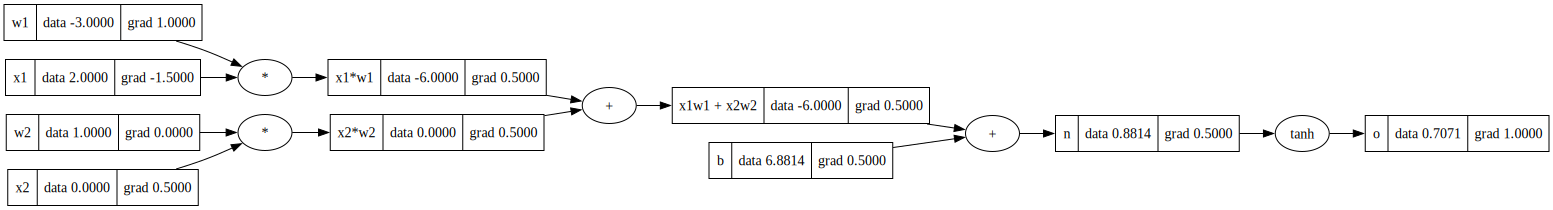

In [195]:
draw_dot(o)

### Edge Case Testing: Accumulating Gradients

We need to ensure our engine handles a critical edge case. What happens if the exact same variable is used multiple times in an expression? 

In $b = a + a$, the derivative of $b$ with respect to $a$ should be 2. If we just overwrote the gradient during backprop, we'd get 1. This is why we use `+=` in our `_backward` functions to *accumulate* the gradients. Let's test it to make sure `a.grad` correctly evaluates to 2.

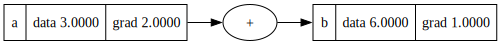

In [211]:
# another example

a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

### Testing a Deeper Computation Graph

Next, let's test a slightly more complex multi-step graph to ensure our topological sort correctly orders the nodes during the `.backward()` pass. 

We will build the expression $f = (a \cdot b) \cdot (a + b)$ and visualize the resulting graph.

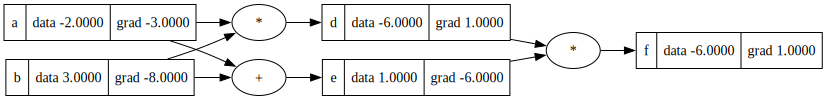

In [212]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)

### Breaking Down the Tanh Function

Now, let's return to our single neuron. Earlier, we used a single composite operation for the activation function: `o = n.tanh()`. 

To truly prove the robustness of our autograd engine, let's remove the `tanh` shortcut. Mathematically, $\tanh(x)$ is defined using exponentials:
$$\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}$$

If our engine is built correctly, we should be able to spell out this exact math using our custom `.exp()`, addition, and division methods, and get the exact same gradients as we did with the composite `.tanh()` function. Let's build it.

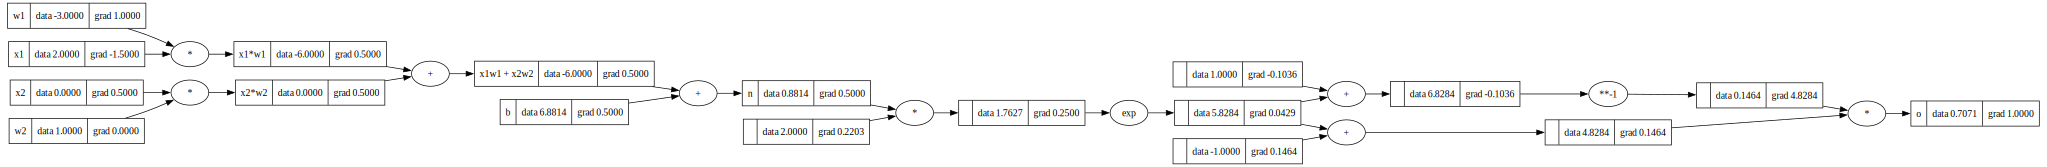

In [220]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870196432, label='b')

# ops
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

## Validating Against PyTorch

To ensure our custom `Value` object and autograd engine are mathematically sound, we replicate the exact same computation graph using PyTorch's tensor API. The resulting gradients should match our scratch-built engine perfectly.

In [221]:
import torch

In [225]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870196432]).double()  ; b.requires_grad = True
n = x1*w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## Building the Neural Network

With the autograd engine complete, we can build higher-level neural network modules. This closely mirrors PyTorch's `nn.Module` API.

* **Neuron:** Computes the dot product of inputs $x$ and weights $w$, adds a bias $b$, and applies a $\tanh$ non-linearity: 
    $$out = \tanh(\sum (w_i \cdot x_i) + b)$$
* **Layer:** A collection of independent Neurons evaluating the same input array.
* **MLP (Multi-Layer Perceptron):** A sequence of Layers where the output of one layer becomes the input to the next.# building neural network in micrograd

In [472]:
import random

class Neuron:
    def __init__(self, n_input):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(n_input)]
        self.b = Value(random.uniform(-1, 1))
        
    def __call__(self, x):
        # w * x + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, n_input, n_output):
        self.neurons = [Neuron(n_input) for _ in range(n_output)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if  len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params
    
class MLP:
    def __init__(self, n_input, n_output):
        size = [n_input] + n_output
        self.layers = [Layer(size[i], size[i+1]) for i in range(len(n_output))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

### Initialize the Network

Let's initialize a Multi-Layer Perceptron with 3 inputs, two hidden layers of 4 neurons each, and 1 output neuron. We will also count the total number of trainable parameters (weights and biases).

In [493]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data = -0.44671668477519194)

In [494]:
len(n.parameters())

41

### Create a Tiny Dataset

In [495]:
xs = [
	[2.0, 3.0, -1.0],
	[3.0, -1.0, 0.5],
	[0.5, 1.0, 1.0],
	[1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

## Training Loop

To train the network, we need an objective measure of its performance. We use an un-averaged **Squared Error** as our loss function for this simple dataset:
$$L = \sum (y_{pred} - y_{target})^2$$

In the training loop, we iteratively:
1.  **Forward Pass:** Compute predictions and calculate the loss.
2.  **Zero Gradients:** Clear previous gradients (otherwise they accumulate in our `Value` objects).
3.  **Backward Pass:** Compute the gradient of the loss with respect to all network parameters using `loss.backward()`.
4.  **Gradient Descent Update:** Adjust parameters in the opposite direction of the gradient by a small step size (learning rate, $\alpha$):
    $$w = w - \alpha \cdot \frac{\partial L}{\partial w}$$

In [496]:
for k in range(60):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    
    # update gradients (gradient descent)
    for p in n.parameters():
        p.data += -0.05 * p.grad
        
    print(k, loss.data)

0 4.626491829738744
1 3.477938377449214
2 2.5644311836944205
3 1.7255472984756675
4 0.950719675089835
5 0.5229657800194966
6 0.3134273013846868
7 0.23098307022981152
8 0.17950981499114407
9 0.14500687272478213
10 0.12060579211330866
11 0.10260811196321229
12 0.08888016726579125
13 0.07811924714437168
14 0.06949168279040117
15 0.062442526879586846
16 0.05658983460171518
17 0.05166311872607157
18 0.047466042479985274
19 0.043852996829687255
20 0.04071393634457973
21 0.037964292623100054
22 0.03553810227478898
23 0.03338322374933689
24 0.031457943561818844
25 0.02972852628664919
26 0.028167417911607394
27 0.02675190937602859
28 0.025463129373411858
29 0.02428527616380463
30 0.02320502519347382
31 0.02221106762058063
32 0.02129374741995032
33 0.020444773504322174
34 0.019656989489870085
35 0.018924188160572182
36 0.01824096088831502
37 0.01760257460720548
38 0.01700487067013664
39 0.01644418120530222
40 0.015917259560572165
41 0.015421222159682897
42 0.014953499657011026
43 0.0145117957112

In [497]:
ypred

[Value(data = 0.9721628576792609),
 Value(data = -0.9451084104649465),
 Value(data = -0.9419561528091737),
 Value(data = 0.9488321793493183)]

## TensorGrad

Our scalar-based `Value` engine works correctly, but operating on single numbers with loops is inefficient. Modern neural networks rely on large-scale matrix operations, so we upgrade to **NumPy tensors (n-dimensional arrays)** for significant performance improvements.

---

### Matrix Multiplication (`__matmul__`)

**Forward Pass:**

The core operation in deep learning is matrix multiplication:

$$
C = A \cdot B
$$

**Backward Pass:**

Gradients require transposed matrices to align shapes correctly:

- Gradient w.r.t. $A$:
$$
\frac{\partial L}{\partial A} = \frac{\partial L}{\partial C} \cdot B^T
$$

- Gradient w.r.t. $B$:
$$
\frac{\partial L}{\partial B} = A^T \cdot \frac{\partial L}{\partial C}
$$

---

### Element-wise Addition & Subtraction (`__add__`, `__sub__`)

**Forward Pass:**

Operations are applied element-by-element:

$$
C = A + B \quad \text{or} \quad C = A - B
$$

**Backward Pass:**

- Gradients flow equally for addition
- For subtraction, one side gets a negative gradient

**Important (Broadcasting):**

If broadcasting occurs (e.g., adding a $1 \times N$ bias to an $M \times N$ matrix), gradients must be **summed across broadcasted dimensions** to match original shapes.

---

### Element-wise Multiplication (`__mul__`)

**Forward Pass:**

Also known as the Hadamard product:

$$
C = A \odot B
$$

**Backward Pass:**

- Gradient w.r.t. $A$ is $B$
- Gradient w.r.t. $B$ is $A$

As with addition, apply summation over broadcasted dimensions when necessary.

---

### Sum Reduction (`sum`)

**Forward Pass:**

Reduces a tensor to a scalar:

$$
S = \sum X
$$

**Backward Pass:**

The scalar gradient is distributed across all elements:

$$
\frac{\partial L}{\partial X} = \text{ones\_like}(X) \cdot \frac{\partial L}{\partial S}
$$

---

### ReLU Activation (`relu`)

**Forward Pass:**

$$
R(x) = \max(0, x)
$$

**Backward Pass:**

$$
\frac{dR}{dx} =
\begin{cases}
1 & \text{if } x > 0 \\
0 & \text{otherwise}
\end{cases}
$$

Gradients only pass through positive inputs.

---

### Tanh Activation (`tanh`)

**Forward Pass:**

Applied element-wise:

$$
t = \tanh(x)
$$

**Backward Pass:**

Same as scalar case:

$$
\frac{d}{dx}(\tanh(x)) = 1 - t^2
$$

In [ ]:
import numpy as np

class Tensor:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = np.array(data, dtype=np.float64)
        self.grad = np.zeros_like(self.data)
        
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Tensor(shape={self.data.shape}, label='{self.label}')\n{self.data}"
    
    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data + other.data, (self, other), '+')
        
        def _backward():
            # Route gradients and handle dimensional broadcasting
            if self.data.shape == out.data.shape:
                self.grad += out.grad
            else:
                self.grad += np.sum(out.grad, axis=0, keepdims=True).reshape(self.data.shape)
                
            if other.data.shape == out.data.shape:
                other.grad += out.grad
            else:
                other.grad += np.sum(out.grad, axis=0, keepdims=True).reshape(other.data.shape)
        
        out._backward = _backward
        return out
    
    def __matmul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data @ other.data, (self, other), '@')
        
        def _backward():
            # Apply chain rule for matrix multiplication via transposes
            self.grad += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad

        out._backward = _backward
        return out
    
    def tanh(self):
        t = np.tanh(self.data)
        out = Tensor(t, (self,), 'tanh')
        
        def _backward():
            # Local derivative of tanh(x) is 1 - tanh^2(x)
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
        return out

    def relu(self):
        out = Tensor(np.maximum(0, self.data), (self,), 'relu')
        
        def _backward():
            # Local derivative of ReLU is 1 for x > 0, else 0
            self.grad += (self.data > 0) * out.grad
            
        out._backward = _backward
        return out
    
    def sum(self):
        out = Tensor(np.sum(self.data), (self,), 'sum')
        
        def _backward():
            # Distribute the scalar gradient equally to all elements
            self.grad += np.ones_like(self.data) * out.grad
            
        out._backward = _backward
        return out
    
    def __sub__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data - other.data, (self, other), '-')
        
        def _backward():
            if self.data.shape == out.data.shape:
                self.grad += out.grad
            else:
                self.grad += np.sum(out.grad, axis=0, keepdims=True).reshape(self.data.shape)
                
            if other.data.shape == out.data.shape:
                other.grad -= out.grad 
            else:
                other.grad -= np.sum(out.grad, axis=0, keepdims=True).reshape(other.data.shape)
            
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data * other.data, (self, other), '*')
        
        def _backward():
            # Apply product rule and handle dimensional broadcasting
            if self.data.shape == out.data.shape:
                self.grad += other.data * out.grad
            else:
                self.grad += np.sum(other.data * out.grad, axis=0, keepdims=True).reshape(self.data.shape)
                
            if other.data.shape == out.data.shape:
                other.grad += self.data * out.grad
            else:
                other.grad += np.sum(self.data * out.grad, axis=0, keepdims=True).reshape(other.data.shape)
            
        out._backward = _backward
        return out
    
    def __neg__(self):
        return self * -1.0
    
    def __radd__(self, other):
        return self + other
    
    def __rsub__(self, other):
        return other + (-self)
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data / other.data, (self, other), '/')
        
        def _backward():
            if self.data.shape == out.data.shape:
                self.grad += (1.0 / other.data) * out.grad
            else:
                self.grad += np.sum((1.0 / other.data) * out.grad, axis=0, keepdims=True).reshape(self.data.shape)
                
            if other.data.shape == out.data.shape:
                other.grad += (-self.data / (other.data ** 2)) * out.grad
            else:
                other.grad += np.sum((-self.data / (other.data ** 2)) * out.grad, axis=0, keepdims=True).reshape(other.data.shape)
                
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # Seed the output gradient
        self.grad = np.ones_like(self.data)
        
        # Traverse the DAG in reverse topological order
        for node in reversed(topo):
            node._backward()

### Validating `Tensor` Class

Before building the full network architecture, we must verify that our `Tensor` engine correctly computes gradients for matrix multiplication. In backpropagation, the dimensional shapes of the gradients must perfectly match the shapes of the original forward-pass tensors. Let's simulate a single linear projection and inspect the dimensions.

In [2]:
# Simulate a batch of 3 samples, each with 4 features
X = Tensor(np.random.randn(3, 4), label='X_input')

# Simulate a weight matrix projecting 4 features to 5 output dimensions
W = Tensor(np.random.randn(4, 5), label='W_weights')

# Forward pass: Matrix multiplication
Out = X @ W
Out.label = 'Out_activations'

# Backward pass
Out.backward()

print("--- Forward Pass Shapes ---")
print(f"X shape:   {X.data.shape}")
print(f"W shape:   {W.data.shape}")
print(f"Out shape: {Out.data.shape}")

print("\n--- Backward Pass Shapes (Gradients) ---")
print(f"dL/dW shape: {W.grad.shape} (Matches W)")
print(f"dL/dX shape: {X.grad.shape} (Matches X)")

--- Forward Pass Shapes ---
X shape:   (3, 4)
W shape:   (4, 5)
Out shape: (3, 5)

--- Backward Pass Shapes (Gradients) ---
dL/dW shape: (4, 5) (Matches W)
dL/dX shape: (3, 4) (Matches X)


### Visualizing the Computation Graph

Before jumping into building full neural network layers, let's verify our tensor engine by visualizing the computation graph of a simple linear equation: a single matrix projection and bias addition ($Z = X \cdot W + b$). 

After verifying this simple case, we will use this same engine to build and evaluate much more complex network architectures. For those massive networks, our visualization utility will intelligently default to displaying only the matrix *shapes* to keep the graphs clean and readable!

In [8]:
import numpy as np
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_tensor(root, show_data=False):
    """
    Visualizes a Tensor computation graph. 
    By default, only shows shapes to keep massive networks readable.
    Set show_data=True to print the actual matrices and gradients.
    """
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        shape_str = str(n.data.shape)
        
        if show_data:
            data_str = np.array2string(n.data, precision=4, suppress_small=True).replace('\n', '\\n')
            grad_str = np.array2string(n.grad, precision=4, suppress_small=True).replace('\n', '\\n')
            
            label = "{%s | shape %s | data:\\n%s | grad:\\n%s}" % (n.label, shape_str, data_str, grad_str)
        else:
            label = "{%s | shape %s}" % (n.label, shape_str)
            
        dot.node(name=uid, label=label, shape='record')
        
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

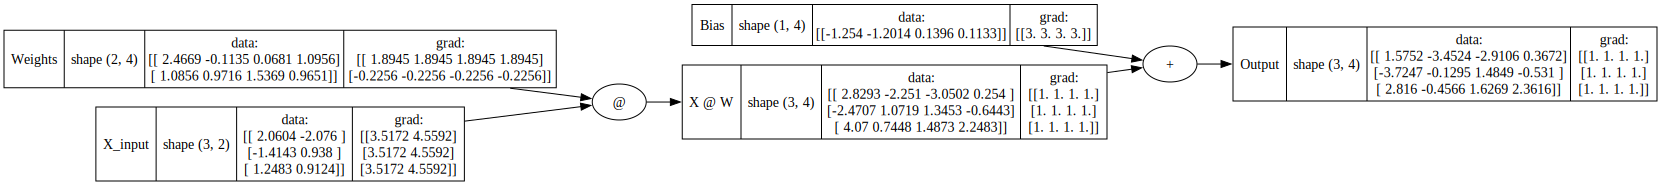

In [11]:
X = Tensor(np.random.randn(3, 2), label='X_input')

W = Tensor(np.random.randn(2, 4), label='Weights')

b = Tensor(np.random.randn(1, 4), label='Bias')

# perform the computation: (X @ W) + b
Z = X @ W; Z.label = 'X @ W'
Out = Z + b; Out.label = 'Output'

# run backprop to populate gradients
Out.backward()

# visualize
draw_tensor(Out, show_data=True)

## Building the Neural Network

With a functioning tensor engine, we can now discard the scalar `Neuron` class. By representing weights as matrices and biases as vectors, an entire layer's forward pass reduces to a single, highly optimized mathematical operation:
$$Out = X \cdot W + b$$

We encapsulate this logic in a `Linear` class, mirroring the design of `torch.nn.Linear`.

In [3]:
class Linear:
    def __init__(self, nin, nout):
        self.W = Tensor(np.random.randn(nin, nout) * 0.1, label='W')
        self.b = Tensor(np.random.randn(1, nout) * 0.1, label='b')
        
    def __call__(self, x):
        # Forward pass: (batch_size, nin) @ (nin, nout) + (1, nout)
        return (x @ self.W) + self.b
    
    def parameters(self):
        return [self.W, self.b]


class VectorizedMLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Linear(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            # Apply non-linearity to all hidden layers, leaving the output layer linear
            if i < len(self.layers) - 1:
                x = x.tanh() 
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

### Create Example Dataset

In our scalar engine, we processed data one sample at a time. Now, we aggregate our entire dataset into a single input matrix $X$ and a target matrix $Y$. 

* $X$ has shape `(4, 3)`: 4 samples, 3 features each.
* $Y$ has shape `(4, 1)`: 4 corresponding target labels.

In [4]:
xs = Tensor([
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
], label='X_batch')

ys = Tensor([
    [1.0],
    [-1.0],
    [-1.0],
    [1.0]
], label='Y_batch')

## Training Loop

In [5]:
# 3 inputs, two hidden layers of 4, 1 output
model = VectorizedMLP(3, [4, 4, 1])

# training hyperparameters
learning_rate = 0.05
epochs = 100

for k in range(epochs):
    # forward pass
    ypred = model(xs)
    
    # compute loss
    diff = ypred - ys
    squared_error = diff * diff
    loss = squared_error.sum()
    
    # zero grad
    for p in model.parameters():
        p.grad = np.zeros_like(p.data)
        
    # backward pass
    loss.backward()
    
    #  update grads
    for p in model.parameters():
        p.data += -learning_rate * p.grad
        
    # logging
    if k % 10 == 0 or k == epochs - 1:
        print(f"Step {k:3d} | Loss: {loss.data:.4f}")

print("\n--- Final Predictions ---")
print(ypred.data)

Step   0 | Loss: 4.0537
Step  10 | Loss: 2.4907
Step  20 | Loss: 0.0562
Step  30 | Loss: 0.0175
Step  40 | Loss: 0.0125
Step  50 | Loss: 0.0096
Step  60 | Loss: 0.0072
Step  70 | Loss: 0.0053
Step  80 | Loss: 0.0036
Step  90 | Loss: 0.0023
Step  99 | Loss: 0.0015

--- Final Predictions ---
[[ 1.02406184]
 [-0.99673613]
 [-1.00456349]
 [ 0.97098832]]
